In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
df = pd.read_csv('marketing_sales_data.csv')
df  = df.dropna()

In [3]:
df.head(10)

,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


In [4]:
df.shape

(569, 5)

In [5]:
df.describe

<bound method NDFrame.describe of          TV      Radio  Social Media Influencer       Sales
0       Low   1.218354      1.270444      Micro   90.054222
1    Medium  14.949791      0.274451      Macro  222.741668
2       Low  10.377258      0.061984       Mega  102.774790
3      High  26.469274      7.070945      Micro  328.239378
4      High  36.876302      7.618605       Mega  351.807328
..      ...        ...           ...        ...         ...
567    High  28.210738      4.373466      Micro  302.887998
568  Medium  23.578661      2.856657       Mega  232.555023
569     Low   9.169824      0.067279       Nano   73.888838
570     Low  11.563403      1.727947       Nano  121.949570
571  Medium  18.814801      3.440682       Mega  182.511614

[569 rows x 5 columns]>

In [6]:
df['Influencer'].value_counts()

Influencer
Nano     147
Mega     147
Micro    145
Macro    130
Name: count, dtype: int64

In [7]:
df['TV'].value_counts()

TV
Medium    197
Low       196
High      176
Name: count, dtype: int64

In [8]:
df.groupby('Influencer').mean(['Sales','Social Media','Radio']).reset_index()

,Influencer,Radio,Social Media,Sales
0,Macro,19.541564,3.487949,206.641805
1,Mega,17.333612,3.041470,180.385096
2,Micro,19.090849,3.332105,198.655080
3,Nano,18.502993,3.129578,189.742830


In [9]:
df.groupby('TV').mean(['Sales','Social Media','Radio']).reset_index()

,TV,Radio,Social Media,Sales
0,High,28.718809,4.726975,300.529591
1,Low,9.066538,1.909308,91.716309
2,Medium,19.010180,3.236349,199.023461


In [10]:
df.isna()

,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


In [11]:
df.isna().any().sum()

np.int64(0)

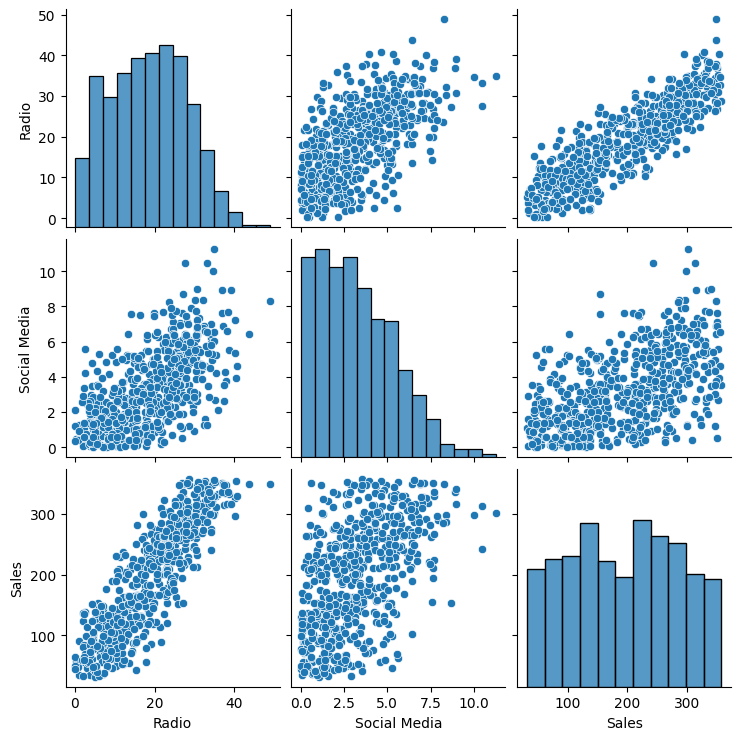

In [12]:
sns.pairplot(df)

In [13]:
rel_data = df[['Sales', 'Radio']]

<Axes: xlabel='Radio', ylabel='Sales'>

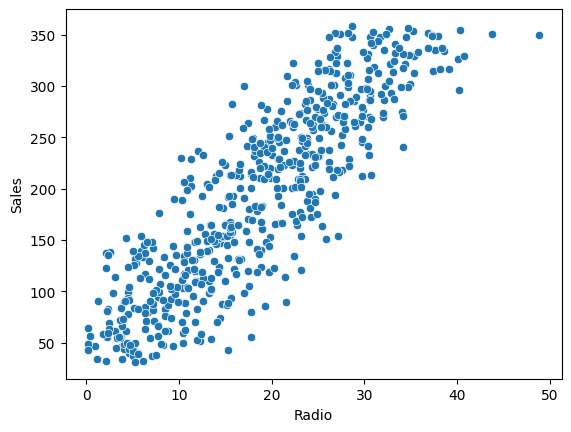

In [14]:
sns.scatterplot(data = rel_data, x = 'Radio', y = 'Sales')

In [15]:
lin_form = 'Radio ~ Sales'
OLS = ols(formula=lin_form, data=rel_data)
model = OLS.fit()

In [16]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Radio   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Fri, 15 May 2026   Prob (F-statistic):          2.07e-176
Time:                        14:54:27   Log-Likelihood:                -1692.1
No. Observations:                 569   AIC:                             3388.
Df Residuals:                     567   BIC:                             3397.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6660      0.470      1.416      0.157      -0.258       1.590
Sales          0.0926      0.002     42.048      0.000       0.088       0.097
==============================================================================
Omnibus:                        2.383   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.304   Jarque-Bera (JB):                2.463
Skew:                           0.147   Prob(JB):                        0.292
Kurtosis:                       2.870   Cond. No.                         505.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='Radio', ylabel='Sales'>

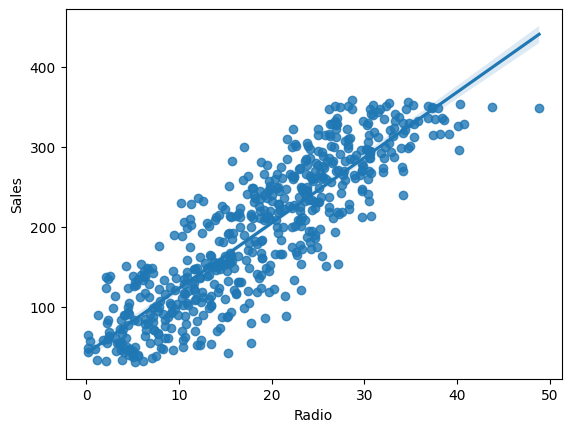

In [17]:
sns.regplot(data = rel_data, x = 'Radio' , y ='Sales' )

In [18]:
X = rel_data['Sales']

In [19]:
fitted_values = model.predict(X)

In [20]:
residuals = model.resid

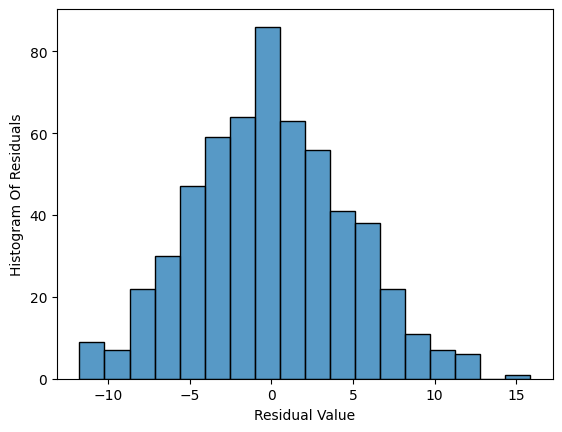

In [21]:
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_ylabel("Histogram Of Residuals")
plt.show()

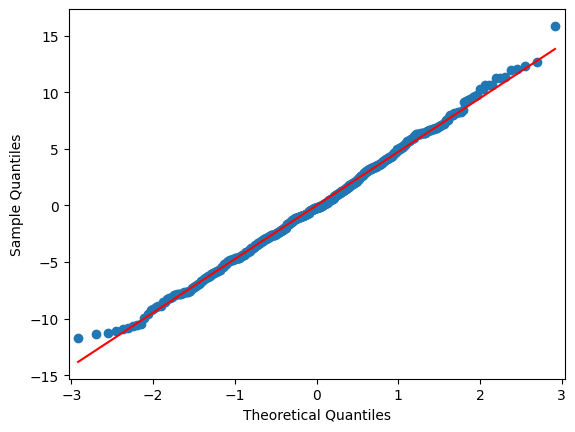

In [22]:
fig = sm.qqplot(model.resid, line= "s")
plt.show()

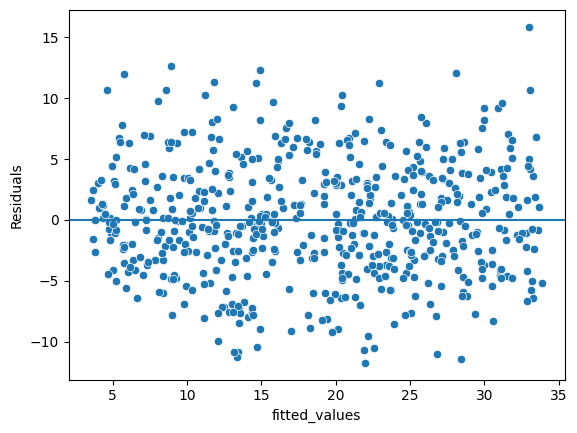

In [23]:
fig  = sns.scatterplot(x = fitted_values, y = residuals)
fig.axhline(0)
fig.set_xlabel("fitted_values")
fig.set_ylabel("Residuals")
plt.show()

In [24]:
lin_form2 = "Sales ~ Radio"

In [25]:
OLS2 = ols(formula=lin_form2, data=rel_data)
model2 = OLS2.fit()

In [26]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Fri, 15 May 2026   Prob (F-statistic):          2.07e-176
Time:                        14:54:28   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
model2

In [28]:
residuals2 = model2.resid

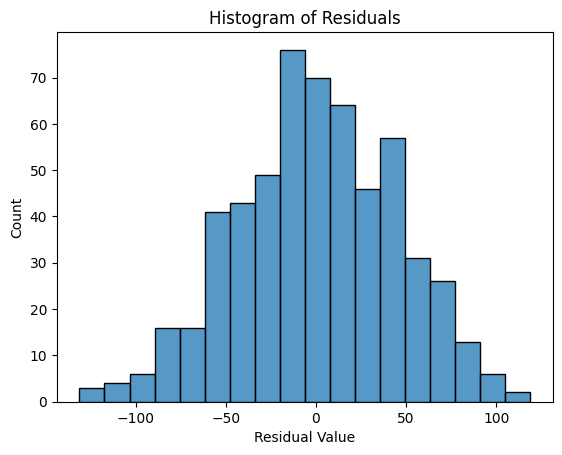

In [29]:
fig = sns.histplot(residuals2)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

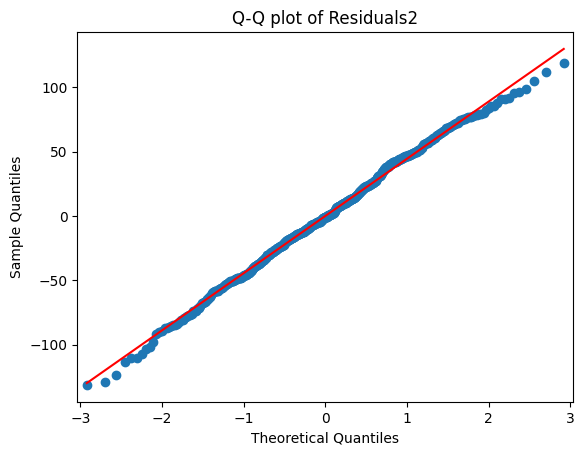

In [30]:
sm.qqplot(residuals2, line='s')
plt.title("Q-Q plot of Residuals2")
plt.show()